In [65]:
# Data Preprocessing
# ==============================================================================
import pandas as pd
import numpy as np

# Plot
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Data
# ==============================================================================
from sklearn.datasets import make_classification

# Model
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

# Metric
# ==============================================================================
from sklearn.metrics import roc_curve

# **Info**
---
@By: **Steven Bernal**

@Nickname: **Kaiziferr**

@Git: https://github.com/Kaiziferr

In [66]:
random_seed = 12345
sns.set_style('darkgrid')

# **Data**
---

Definition of general parameters

In [67]:
n_samples = 500
n_features = 20
n_informative = 5
n_redundant = 5
n_repeated = 0
n_classes = 2
random_state = 42

def generar_dataset(class_sep:int, flip_y: int, name: str)->pd.DataFrame:
    X, y = make_classification(n_samples=n_samples, n_features=n_features,
                               n_informative=n_informative, n_redundant=n_redundant,
                               n_repeated=n_repeated, n_classes=n_classes,
                               n_clusters_per_class=2,
                               class_sep=class_sep, flip_y=flip_y,
                               random_state=random_state)
    df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(1, n_features+1)])
    df['target'] = y
    df['dataset'] = name
    return df


# **Case 1**
---

Definition of Case 1. It is a set of synthetic data that is well separated into two categories.

In [68]:
data = generar_dataset(class_sep=3.0, flip_y=0.0, name='Perfectamente separables')

**Split Data**

In [69]:
X = data.iloc[:, :-2]
y = data['target']

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed)

**Model**

In [71]:
model_forest = RandomForestClassifier().fit(X_train, y_train)
model_log = LogisticRegression().fit(X_train, y_train)
model_tree = DecisionTreeClassifier().fit(X_train, y_train)
model_dummy = DummyClassifier(strategy='uniform').fit(X_train, y_train)

In [72]:
model_forest

RandomForestClassifier()

In [73]:
y_pred_forest = model_forest.predict_proba(X_test)[:,1]
y_pred_log = model_log.predict_proba(X_test)[:,1]
y_pred_tree = model_tree.predict_proba(X_test)[:,1]
y_dummy = model_dummy.predict_proba(X_test)[:,1]

In [74]:
model_forest.classes_, model_log.classes_, model_tree.classes_, model_dummy.classes_

(array([0, 1]), array([0, 1]), array([0, 1]), array([0, 1]))

In [75]:
def roc_curve_plot(
    y_true:np.array,
    y_pred:list,
    labels:list,
    color:list=None,
    size:tuple=(10,5),
    threshold_prede:list=[0, 1],
    **Kwargs)-> None:
    """
      Plot ROC curves for one or multiple prediction sets.

      Parameters
      ----------
      y_true : numpy.array
          Array of true binary labels.

      y_pred : list
          List of arrays containing predicted scores or probabilities
          for each model.

      labels : list
          List of labels for each ROC curve.

      color : list, default=None
          List of colors for each curve.
          If None, default matplotlib colors are used.

      size : tuple, default=(10, 5)
          Figure size as (width, height).

      threshold_prede : list, default=[0, 1]
          Values used to plot the diagonal reference line
          representing random guessing.

      **Kwargs : dict
          Additional keyword arguments passed to sklearn.metrics.roc_curve.

      Returns
      -------
      None
          Displays the ROC curve plot.
    """
    try:
      fig, ax = plt.subplots(figsize = size)

      data = []

      for i in range(len(y_pred)):
        fpr, tpr, thresholds = roc_curve(y_true, y_pred[i], **Kwargs)
        if color:
          plt.plot(fpr, tpr, "--", label=labels[i], color=color[i])
        else:
          plt.plot(fpr, tpr, label=labels[i])

      plt.plot(threshold_prede, threshold_prede   , 'k:', label='Random guess')
      plt.xlabel('False Positive Rate')
      plt.ylabel('True Positive Rate')
      plt.title('ROC Curve')
      plt.legend()
      plt.show()

    except Exception as e:
      raise e

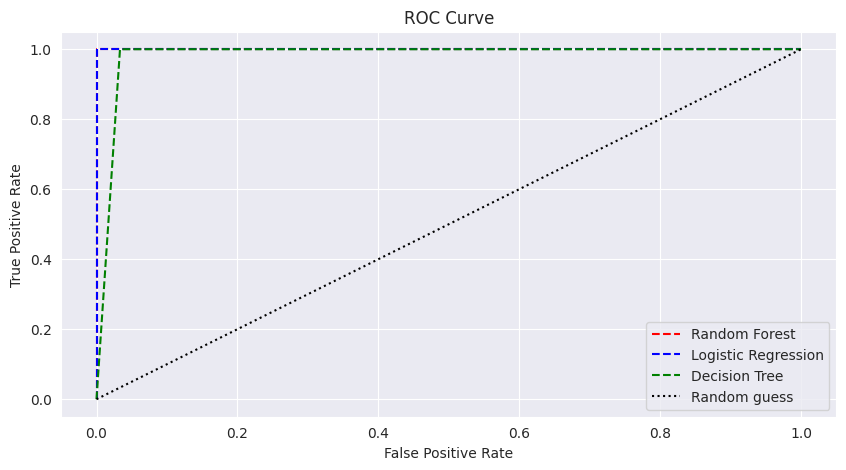

In [76]:
prd = [y_pred_forest, y_pred_log, y_pred_tree]
labes = ["Random Forest", "Logistic Regression", "Decision Tree"]
color=["red", "blue", "green", "black"]

roc_curve_plot(y_test, prd, labes, color, **{'pos_label': 1})

**Random Forest**

Random Forest shows a practically perfect ROC curve, located very close to the upper-left corner of the plot. This indicates that it reaches a TPR of 1.0 with an extremely low FPR, reflecting an almost complete separation between classes. In this case, the model achieves clearly superior performance compared to the others, since it does not need to significantly increase false positives to correctly identify all positive cases. Its behavior is highly efficient and stable across the entire range.


**Logistic Regression**

Logistic Regression presents a very similar curve to Random Forest, especially in the initial region. Its growth is almost vertical, reaching the maximum TPR with FPR values close to zero. This suggests that, in this dataset, a linear model is also capable of separating the classes very effectively. No relevant loss in performance is observed compared to more complex models.

**Decision Tree**

The Decision Tree (green) follows a pattern quite close to the other two models, although it is slightly shifted to the right. This implies that it requires a somewhat higher FPR to reach the maximum TPR. Even so, its overall performance is good, and the differences with Random Forest and Logistic Regression are small, suggesting that the problem is highly separable even with simpler models.


**Dummy**

The Dummy model follows the diagonal line, representing performance equivalent to random chance. It has no real ability to distinguish between classes, so there is no meaningful threshold, and any chosen cutoff produces results equivalent to random classification.


# **Case 2**
---

Definition of Case 2. It is a set of synthetic data that is not so well separated into two categories

In [77]:
data = generar_dataset(class_sep=1.5, flip_y=0.05, name='Separables no tan bien')

**Split Data**

In [78]:
X = data.iloc[:, :-2]
y = data['target']

In [79]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed)

**Model**

In [80]:
model_forest = RandomForestClassifier().fit(X_train, y_train)
model_log = LogisticRegression().fit(X_train, y_train)
model_tree = DecisionTreeClassifier().fit(X_train, y_train)
model_dummy = DummyClassifier(strategy='uniform').fit(X_train, y_train)

In [81]:
y_pred_forest = model_forest.predict_proba(X_test)[:,1]
y_pred_log = model_log.predict_proba(X_test)[:,1]
y_pred_tree = model_tree.predict_proba(X_test)[:,1]
y_dummy = model_dummy.predict_proba(X_test)[:,1]

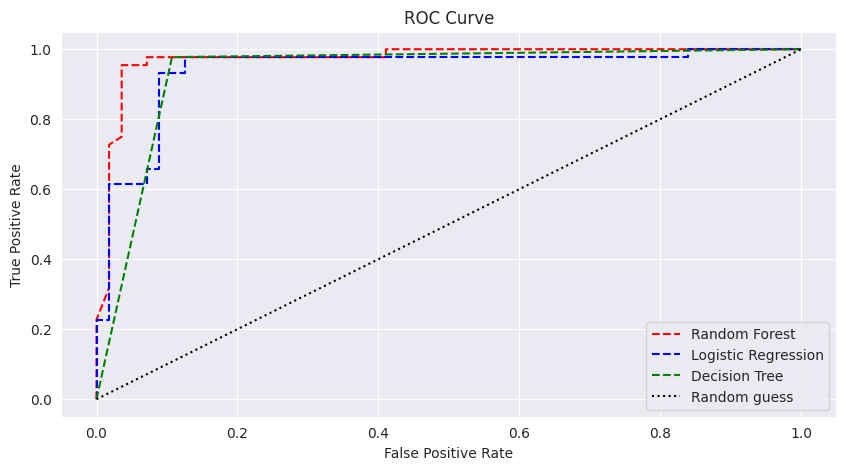

In [82]:
prd = [y_pred_forest, y_pred_log, y_pred_tree]
labes = ["Random Forest", "Logistic Regression", "Decision Tree"]
color=["red", "blue", "green", "black"]

roc_curve_plot(y_test, prd, labes, color, **{'pos_label': 1})

**Random Forest**

This model takes off very quickly right from the beginning. With very few false positives, it already manages to capture almost all the positive cases, which is pretty impressive. In fact, with a very low false positive rate (FPR), around 0.05 to 0.1, it already reaches a true positive rate (TPR) close to 1. It also stays above the other models throughout the entire curve, showing excellent class separation capability. Overall, it’s the most stable and consistent model of the group.

**Logistic Regression**

Logistic Regression, its behavior is a bit more gradual. It doesn’t rise as quickly as Random Forest; instead, it needs to allow more false positives to achieve the same level of detection. Across the curve, it remains slightly below. Still, it’s a solid model, but it’s less flexible and struggles a bit more to separate the classes in more complex cases. For example, to reach a TPR close to 0.95, it requires a higher FPR, around 0.15 to 0.2.

**Decision Tree**

Decision Tree, it shows an interesting pattern. At the beginning, it rises very quickly quite aggressively which means it detects positives early on. However, that improvement slows down afterward, and the curve flattens as it approaches the top. In some segments, it even slightly outperforms Logistic Regression, but overall it doesn’t sustain that performance. This is typical of decision trees: strong initial performance, but less consistency compared to Random Forest.


**Dummy**

Dummy model basically doesn’t do anything useful. Its curve is a diagonal line, which indicates performance equivalent to random chance. It has no real ability to distinguish between classes, and any threshold you choose will give results similar to flipping a coin.


# **Case 3**
---

Definition of Case 3. It is a set of synthetic data that is more or less separable into two categories.

In [83]:
data = generar_dataset(class_sep=1.0, flip_y=0.1, name='Separables más o menos')

**Split Data**

In [84]:
X = data.iloc[:, :-2]
y = data['target']

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed)

**Model**

In [86]:
model_forest = RandomForestClassifier().fit(X_train, y_train)
model_log = LogisticRegression().fit(X_train, y_train)
model_tree = DecisionTreeClassifier().fit(X_train, y_train)
model_dummy = DummyClassifier(strategy='uniform').fit(X_train, y_train)

In [87]:
y_pred_forest = model_forest.predict_proba(X_test)[:,1]
y_pred_log = model_log.predict_proba(X_test)[:,1]
y_pred_tree = model_tree.predict_proba(X_test)[:,1]
y_dummy = model_dummy.predict_proba(X_test)[:,1]

In [88]:
prd = [y_pred_forest, y_pred_log, y_pred_tree]
labes = ["Random Forest", "Logistic Regression", "Decision Tree"]
color=["red", "blue", "green", "black"]

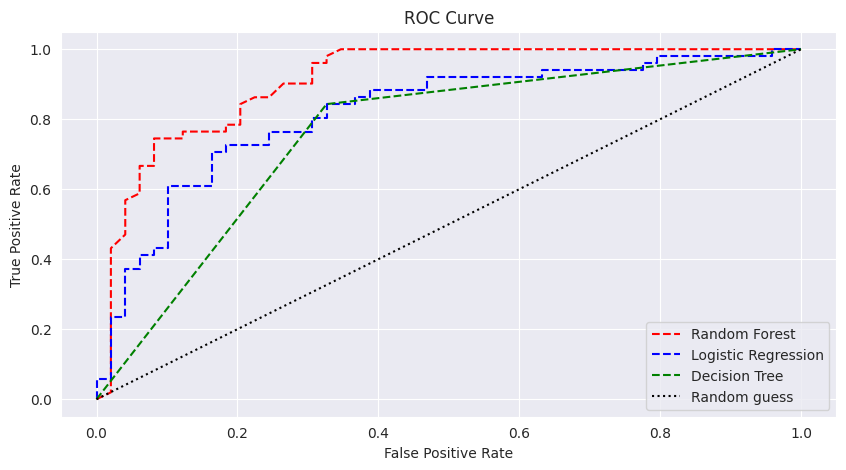

In [89]:
roc_curve_plot(y_test, prd, labes, color, **{'pos_label': 1})


**Random Forest**

Random Forest shows a clearly dominant ROC curve, positioned closer to the upper-left corner. This behavior indicates a rapid increase in TPR even with small increases in FPR. In terms of performance, it reflects an excellent ability to separate classes, as it manages to identify a high proportion of positives without significantly increasing false positives in the early stages.

The efficient operating region is approximately observed between an FPR of 0.10 to 0.15 and a TPR of 0.80 to 0.90. In this context, the optimal threshold is estimated to be between 0.45 and 0.55, with 0.5 being a reasonable reference value.



**Logistic Regression**

Logistic Regression shows a curve above the diagonal, although below Random Forest. The increase in TPR is more gradual, without a sharp rise in the early sections of the curve. This indicates moderate discriminative ability: the model can separate the classes, but with lower efficiency.

Its efficient operating region is approximately between an FPR of 0.20 to 0.30 and a TPR of 0.70 to 0.80. The optimal threshold lies in the range of 0.4 to 0.5, with 0.5 considered a general reference point.



**Decision Tree**

The Decision Tree presents a curve closer to the diagonal, which indicates a lower ability to discriminate between classes. The increase in TPR is more directly tied to increases in FPR, suggesting limitations in separating positives from negatives.

The observed efficient region is approximately between an FPR of 0.30 to 0.40 and a TPR of 0.75 to 0.85. The optimal threshold is estimated between 0.30 and 0.40, although 0.5 can still be considered a standard reference.



**Dummy**

The Dummy model follows a diagonal line, representing performance equivalent to random chance. There is no real ability to distinguish between classes, so any threshold produces results similar to random classification—equivalent to flipping a coin.


# **Case 4**
---

Definition of Case 4. It is a set of synthetic data that is poorly separable into two categories.

In [90]:
data = generar_dataset(class_sep=0.5, flip_y=0.3, name='No separables')

**Split Data**

In [91]:
X = data.iloc[:, :-2]
y = data['target']

In [92]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed)

**Model**

In [93]:
model_forest = RandomForestClassifier().fit(X_train, y_train)
model_log = LogisticRegression().fit(X_train, y_train)
model_tree = DecisionTreeClassifier().fit(X_train, y_train)
model_dummy = DummyClassifier(strategy='uniform').fit(X_train, y_train)

In [94]:
y_pred_forest = model_forest.predict_proba(X_test)[:,1]
y_pred_log = model_log.predict_proba(X_test)[:,1]
y_pred_tree = model_tree.predict_proba(X_test)[:,1]
y_dummy = model_dummy.predict_proba(X_test)[:,1]

In [95]:
prd = [y_pred_forest, y_pred_log, y_pred_tree]
labes = ["Random Forest", "Logistic Regression", "Decision Tree"]
color=["red", "blue", "green", "black"]

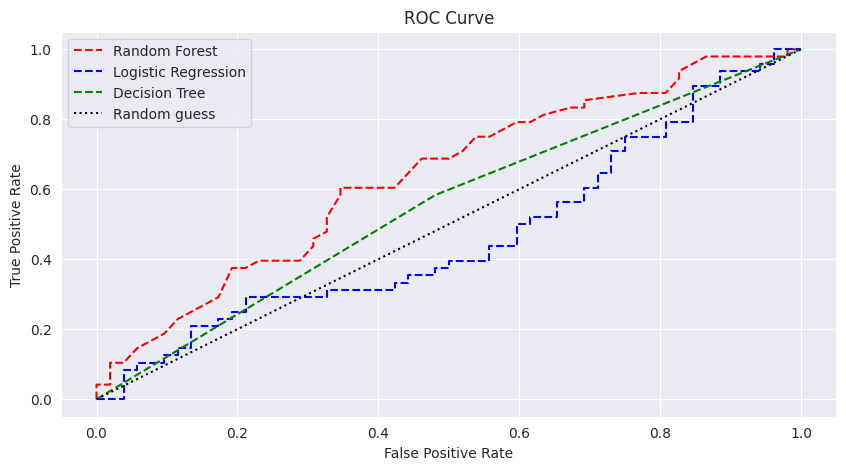

In [96]:
roc_curve_plot(y_test, prd, labes, color, **{'pos_label': 1})

**Random Forest**

Random Forest presents the best curve among the three models. Its initial behavior is the most favorable, as it increases the TPR more rapidly at low FPR values. However, compared to other plots, the separation between classes is not as pronounced as in previous cases, suggesting a strong but not extremely distinctive performance across the entire range.

**Logistic Regression**

Logistic Regression is the worst-performing model overall among the three. Its curve is flatter and remains close to the diagonal for most of the range, indicating a clear difficulty in separating the classes. This behavior suggests that the relationship between variables is likely non-linear, which limits its predictive capability.

**Decision Tree**

The Decision Tree shows an intermediate behavior. During the first half of the curve, it stays quite close to Random Forest, indicating good initial performance. However, it later stabilizes slightly below it, losing performance in the mid and high FPR ranges. Overall, it delivers reasonable results, although less consistent than Random Forest.

**Dummy**

The Dummy model follows a diagonal line, representing performance equivalent to random chance. There is no real ability to discriminate between classes, so there is no meaningful threshold, and any chosen cutoff produces results equivalent to random classification.

# **Info**
---
@By: **Steven Bernal**

@Nickname: **Kaiziferr**

@Git: https://github.com/Kaiziferr